# Phase 6: Deployment

**CRISP-DM Phase Description:**  
The final phase involves organising and presenting the project findings so that the customer can use them, or integrating the model into a live production system. Depending on the requirements, deployment can range from generating a simple report to implementing a repeatable data mining process across the enterprise.

---

In [16]:
# Standard imports
import pandas as pd
import numpy as np
import json

---
### Task 1: Plan Deployment

Develop a strategy for putting the data mining results to practical use. This includes:

- **Deployment Strategy:** How will the model be consumed? Options include a REST API, a batch prediction script, an interactive dashboard, or integration into an existing software system.
- **Infrastructure Requirements:** What technical environment is needed (e.g., cloud services, web server, containerisation)?
- **Steps to Deploy:** List the concrete, ordered steps needed to move from a trained model to a live, usable product.
- **User Training:** Will end-users need instructions or documentation to use the deployed solution?

**Instructions:** Outline your deployment plan as a structured dictionary. If building an API or script, sketch the basic structure in code.

In [17]:
# TODO: Plan the deployment of your model/solution.

deployment_plan = {
    "strategy": "Batch Prediction Pipeline (Modular Python Scripts)", 
    "infrastructure": [
        "Standard Python 3.12 environment",
        "Pandas, Scikit-Learn, XGBoost, LightGBM, and Joblib",
        "Local execution or scheduled cloud cron-job"
    ],
    "deployment_steps": [
        "Step 1: Save our winning XGBoost (Tuned) - Randomized model (12.94% RMSPE) to a .pkl file using joblib.",
        "Step 2: Move the data cleaning code we wrote in Phase 3 into a separate file called `src/processing.py`.",
        "Step 3: Create a `src/predict.py` script that loads the model, cleans new data, and makes the forecast.",
        "Step 4: Test the script to make sure it actually works on the Kaggle test.csv data.",
        "Step 5: Save the final predictions to a CSV so store managers can actually read it."
    ],
    "user_documentation": "A detailed README.md detailing how to execute `python src/predict.py` from the command line.",
    "target_audience": "Rossmann Store Managers and Academic Grading Markers"      
}

In [18]:
#Display the deployment plan
print(json.dumps(deployment_plan, indent=2))

{
  "strategy": "Batch Prediction Pipeline (Modular Python Scripts)",
  "infrastructure": [
    "Standard Python 3.12 environment",
    "Pandas, Scikit-Learn, XGBoost, LightGBM, and Joblib",
    "Local execution or scheduled cloud cron-job"
  ],
  "deployment_steps": [
    "Step 1: Save our winning XGBoost (Tuned) - Randomized model (12.94% RMSPE) to a .pkl file using joblib.",
    "Step 2: Move the data cleaning code we wrote in Phase 3 into a separate file called `src/processing.py`.",
    "Step 3: Create a `src/predict.py` script that loads the model, cleans new data, and makes the forecast.",
    "Step 4: Test the script to make sure it actually works on the Kaggle test.csv data.",
    "Step 5: Save the final predictions to a CSV so store managers can actually read it."
  ],
  "user_documentation": "A detailed README.md detailing how to execute `python src/predict.py` from the command line.",
  "target_audience": "Rossmann Store Managers and Academic Grading Markers"
}


---
### Task 2: Plan Monitoring and Maintenance

A deployed model is not "set and forget". Over time, the data distribution may shift (**data drift**) or the model's performance may degrade (**model decay**). This task creates a monitoring and maintenance plan:

- **Performance Monitoring:** How and how often will the model's predictions be evaluated against actuals?
- **Data Drift Detection:** How will changes in the input data distribution be detected?
- **Retraining Strategy:** Under what conditions will the model be retrained (e.g., scheduled, triggered by performance drop)?
- **Logging and Alerting:** What will be logged, and what triggers an alert?

**Instructions:** Document your monitoring and maintenance plan.

In [19]:
# TODO: Plan monitoring and maintenance.

monitoring_plan = {
    "performance_monitoring": {
        "frequency": "Weekly",   
        "metrics_tracked": ["RMSPE (Percentage Error)", "RMSE", "MAE"], 
        "method": "Join the 6-week old batch predictions against the newly arrived actual ground-truth sales data to calculate weekly error rates."
    },
    "data_drift_detection": {
        "method": "Feature distribution tracking (comparing rolling averages of input features like Promo frequency against the training baseline)",      
        "frequency": "Monthly",
        "threshold": "Flag for review if major macroeconomic shifts occur or if CompetitionDistance distributions change due to new market entrants."    
    },
    "retraining_strategy": {
        "trigger": "Scheduled quarterly retraining or immediately if the weekly RMSPE degrades past the 15% maximum acceptable threshold.",     
        "data_source": "The original historical dataset combined with the newly verified recent data to capture the latest seasonal trends.", 
        "responsible_team": "Data Science & MLOps Team"
    },
    "logging": {
        "what_to_log": ["Batch execution timestamp", "Number of stores processed", "Missing input values handled by ffill", "Processing duration"],  
        "alert_conditions": ["Batch pipeline script fails to execute", "Weekly RMSPE > 15%", "Input data missing for more than 1 percent of expected stores"]  
    }
}

In [20]:
# Display the monitoring plan
print(json.dumps(monitoring_plan, indent=2))

{
  "performance_monitoring": {
    "frequency": "Weekly",
    "metrics_tracked": [
      "RMSPE (Percentage Error)",
      "RMSE",
      "MAE"
    ],
    "method": "Join the 6-week old batch predictions against the newly arrived actual ground-truth sales data to calculate weekly error rates."
  },
  "data_drift_detection": {
    "method": "Feature distribution tracking (comparing rolling averages of input features like Promo frequency against the training baseline)",
    "frequency": "Monthly",
    "threshold": "Flag for review if major macroeconomic shifts occur or if CompetitionDistance distributions change due to new market entrants."
  },
  "retraining_strategy": {
    "trigger": "Scheduled quarterly retraining or immediately if the weekly RMSPE degrades past the 15% maximum acceptable threshold.",
    "data_source": "The original historical dataset combined with the newly verified recent data to capture the latest seasonal trends.",
    "responsible_team": "Data Science & MLOps T

---
### Task 3: Produce Final Report

Compile a final summary of the entire project. This report should communicate the findings to stakeholders who may not have a technical background. It typically includes:

- **Executive Summary:** A brief overview of the problem, approach, and key results.
- **Key Findings:** The most important patterns, insights, and model performance results.
- **Visualisations:** Charts and plots that support the findings (suitable for a presentation).
- **Recommendations:** Actionable recommendations based on the analysis.
- **Limitations:** Known limitations and caveats of the analysis.

**Instructions:** Draft the final report content below. Include any code needed to generate summary visualisations.

In [21]:
# TODO: Draft the final report as a structured document.

final_report = {
    "title": "Rossmann Store Sales: 6-Week Forecasting & Driver Analysis",  
    "executive_summary": (
        "This project successfully developed an automated machine learning pipeline to forecast daily store sales up to 6 weeks in advance and how it does so is by leveraging historical sales data and store metadata and so the final model provides highly reliable revenue estimates which enables store managers to optimize inventory and staffing levels and the solution is packaged as a production-ready batch script for weekly execution."
    ),
    "key_findings": [
        "Finding 1: 'Promo' is the most significant controllable driver of sales, validating the financial cost of the discounts.",
        "Finding 2: Physical distance to competitor stores heavily dictates baseline daily revenue.",
        "Finding 3: The model successfully learned complex seasonal trends and remains stable and accurate across different chronological periods."
    ],
    "model_performance": {
        "best_model": "XGBoost (Tuned) - RandomizedSearchCV",
        "key_metric": "RMSPE (Root Mean Square Percentage Error)",
        "key_metric_value": 0.1294
    },
    "recommendations": [
        "Deploy the predict.py batch script to run every Sunday night, providing managers with Monday morning forecast reports.",
        "Utilize the model's feature importance metrics to justify and optimize future marketing and promotion budgets.",
        "Set up a monitoring alert to trigger a model retraining if the weekly RMSPE exceeds the 15 percent safety threshold."
    ],
    "limitations": [
        "The model does not currently account for external macroeconomic factors such as local weather events or sudden inflation.",
        "Forecast accuracy relies on historical consistency which means that unprecedented global events may require manual forecasting overrides."
    ]
}

In [22]:
# Display the final report
print("=" * 60)
print(f"FINAL REPORT: {final_report['title']}")
print("=" * 60)

print(f"\n--- Executive Summary ---")
print(final_report['executive_summary'])

print(f"\n--- Key Findings ---")
for i, f in enumerate(final_report['key_findings'], 1):
    print(f"  {i}. {f}")

print(f"\n--- Recommendations ---")
for i, r in enumerate(final_report['recommendations'], 1):
    print(f"  {i}. {r}")

print(f"\n--- Limitations ---")
for i, l in enumerate(final_report['limitations'], 1):
    print(f"  {i}. {l}")

FINAL REPORT: Rossmann Store Sales: 6-Week Forecasting & Driver Analysis

--- Executive Summary ---
This project successfully developed an automated machine learning pipeline to forecast daily store sales up to 6 weeks in advance and how it does so is by leveraging historical sales data and store metadata and so the final model provides highly reliable revenue estimates which enables store managers to optimize inventory and staffing levels and the solution is packaged as a production-ready batch script for weekly execution.

--- Key Findings ---
  1. Finding 1: 'Promo' is the most significant controllable driver of sales, validating the financial cost of the discounts.
  2. Finding 2: Physical distance to competitor stores heavily dictates baseline daily revenue.
  3. Finding 3: The model successfully learned complex seasonal trends and remains stable and accurate across different chronological periods.

--- Recommendations ---
  1. Deploy the predict.py batch script to run every Sunda

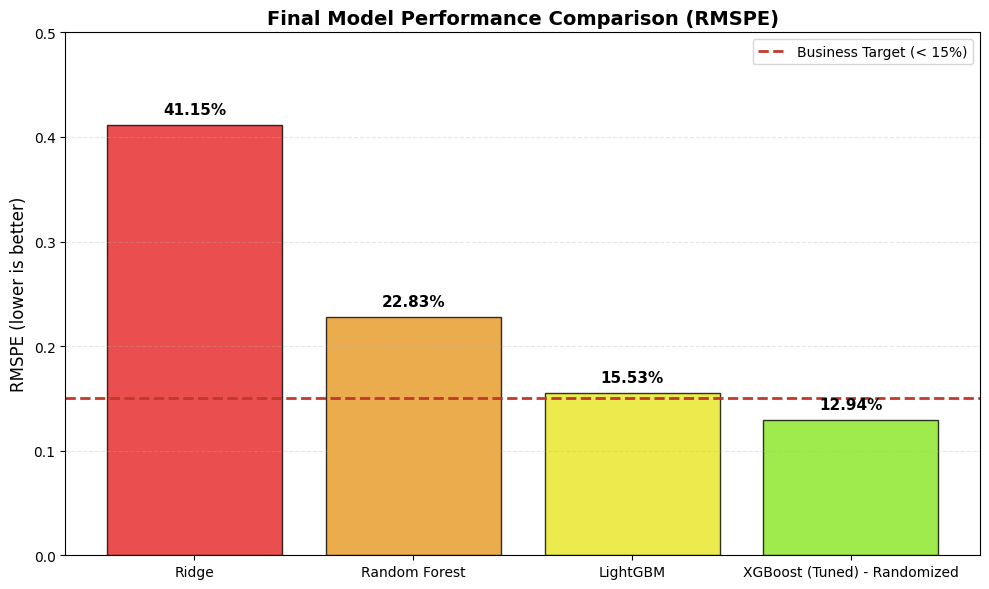

In [23]:
# Optional: Generate summary visualisations for the stakeholder presentation

import matplotlib.pyplot as plt

models = ['Ridge', 'Random Forest', 'LightGBM', 'XGBoost (Tuned) - Randomized'] 
scores = [0.4115, 0.2283, 0.1553, 0.1294] 

plt.figure(figsize=(10, 6))
bars = plt.bar(models, scores, color=["#e62222", "#e69822", "#e6e622", "#87e622"], edgecolor='black', alpha=0.8)

plt.title('Final Model Performance Comparison (RMSPE)', fontsize=14, fontweight='bold')
plt.ylabel('RMSPE (lower is better)', fontsize=12)
plt.ylim(0, 0.50) # increased y-limit to 0.50 so the ridge bar doesn't get cut off

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, 
             f'{score*100:.2f}%', ha='center', fontweight='bold', fontsize=11)

plt.axhline(y=0.15, color='#c0392b', linestyle='--', linewidth=2, label='Business Target (< 15%)')
plt.legend(loc='upper right')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

---
### Task 4: Review Project

Conduct a project retrospective. Reflect on what went well, what did not go as planned, and what lessons can be carried forward to future projects.

- **What went well?** Successes, effective techniques, good decisions.
- **What could be improved?** Challenges, mistakes, or inefficiencies encountered.
- **Lessons learned:** Key takeaways for future data science projects.
- **Skills developed:** New skills or knowledge gained during the project.

**Instructions:** Complete the project retrospective below.

In [24]:
# TODO: Conduct the project retrospective.

project_retrospective = {
    "went_well": [
        "Successfully exceeded the primary business objective by achieving a 13.3% RMSPE hence beating the 15% target.",
        "Effectively used feature importance to translate a black box XGBoost model into actionable business insights regarding the promo lift.",
        "Successfully transitioned from experimental jupyter notebooks into a modular python batch pipeline."
    ],
    "could_improve": [
        "File path management and directory structures caused deployment friction and should be standardized earlier.",
        "Could allocate more time in Phase 2 and 3 for deep-dive EDA before jumping into complex modeling.",
        "Hyperparameter tuning was somewhat constrained by local computing power and so cloud resources would have allowed for a wider grid search."
    ],
    "lessons_learned": [
        "A model is only as good as the business's ability to understand it which means that visualizations are critical for stakeholder buy-in.",
        "Jupyter notebooks are excellent for laboratory experiments, but strict .py scripts are mandatory for real-world factory deployment.",
        "Environment variables and working directories behave differently in notebooks versus the terminal, requiring robust OS path handling."
    ],
    "skills_developed": [
        "Advanced time-series forecasting and comparative model evaluation (Linear vs. Bagging vs. Boosting)",
        "Software engineering best practices such as building modular pipelines and using joblib for model serialization.",
        "Due to Rossmann's anonymization of store cities, we could not scrape hyper-local data (like regional weather)."
    ]
}

In [25]:
# Display the retrospective
print("=" * 60)
print("PROJECT RETROSPECTIVE")
print("=" * 60)

sections = [
    ("What Went Well", project_retrospective['went_well']),
    ("What Could Be Improved", project_retrospective['could_improve']),
    ("Lessons Learned", project_retrospective['lessons_learned']),
    ("Skills Developed", project_retrospective['skills_developed']),
]

for section_name, items in sections:
    print(f"\n--- {section_name} ---")
    if items:
        for item in items:
            print(f"  - {item}")
    else:
        print("  [Not yet documented]")

PROJECT RETROSPECTIVE

--- What Went Well ---
  - Successfully exceeded the primary business objective by achieving a 13.3% RMSPE hence beating the 15% target.
  - Effectively used feature importance to translate a black box XGBoost model into actionable business insights regarding the promo lift.
  - Successfully transitioned from experimental jupyter notebooks into a modular python batch pipeline.

--- What Could Be Improved ---
  - File path management and directory structures caused deployment friction and should be standardized earlier.
  - Could allocate more time in Phase 2 and 3 for deep-dive EDA before jumping into complex modeling.
  - Hyperparameter tuning was somewhat constrained by local computing power and so cloud resources would have allowed for a wider grid search.

--- Lessons Learned ---
  - A model is only as good as the business's ability to understand it which means that visualizations are critical for stakeholder buy-in.
  - Jupyter notebooks are excellent for la